In [8]:
# ==========================================================
# IMPORTS
# ==========================================================
%pip install pyiqa
import os
import cv2
import torch
import joblib
import numpy as np
import pandas as pd
import pyiqa
from PIL import Image
from tqdm import tqdm

from sklearn.metrics.pairwise import cosine_similarity

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

import matplotlib.pyplot as plt
import seaborn as sns

from retinaface import RetinaFace
from insightface.app import FaceAnalysis

# ==========================================================
# PATHS
# ==========================================================

BASE_DIR = "/Users/admin/Desktop/reliable_rejection_under_degradation/verification_mlp/verification_mlp_multilayer/mlp_multilayer_fullExtendedVersion/african_dataset"

GALLERY_DIR = os.path.join(BASE_DIR, "gallery")
PROBE_DIR = os.path.join(BASE_DIR, "probe")

GALLERY_CROPPED = GALLERY_DIR
PROBE_CROPPED = PROBE_DIR

GALLERY_EMBEDDINGS = os.path.join(BASE_DIR, "gallery_embeddings")
PROBE_EMBEDDINGS = os.path.join(BASE_DIR, "probe_embeddings")

CSV_FILE = os.path.join(BASE_DIR, "african_dataset.csv")

FIGURES_DIR = os.path.join(BASE_DIR, "figures")

os.makedirs(GALLERY_CROPPED, exist_ok=True)
os.makedirs(PROBE_CROPPED, exist_ok=True)

os.makedirs(GALLERY_EMBEDDINGS, exist_ok=True)
os.makedirs(PROBE_EMBEDDINGS, exist_ok=True)

os.makedirs(FIGURES_DIR, exist_ok=True)

# ==========================================================
# LOAD ARCFACE
# ==========================================================

app = FaceAnalysis(name="buffalo_l")

app.prepare(
    ctx_id=0 if torch.cuda.is_available() else -1,
    det_size=(640,640),
)

rec_model = app.models["recognition"]

print("ArcFace Loaded")

# ==========================================================
# LOAD MUSIQ
# ==========================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device :", device)

musiq_metric = pyiqa.create_metric(
    "musiq",
    device=device,
)

print("MUSIQ Loaded")

Note: you may need to restart the kernel to use updated packages.
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/admin/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/admin/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/admin/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/admin/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/admin/.insightface/models/buffalo

In [9]:
# ==========================================================
# GENERATE ARCFACE EMBEDDINGS
# ==========================================================


def generate_embeddings(image_dir, embedding_dir):

    total = 0
    success = 0
    failed = 0

    all_images = []

    for person in sorted(os.listdir(image_dir)):

        person_dir = os.path.join(image_dir, person)

        if not os.path.isdir(person_dir):
            continue

        for image_name in sorted(os.listdir(person_dir)):

            if image_name.lower().endswith((".jpg", ".jpeg", ".png")):

                all_images.append((person, image_name))

    for person, image_name in tqdm(
        all_images,
        desc="Generating Embeddings"
    ):

        person_dir = os.path.join(image_dir, person)

        save_person = os.path.join(
            embedding_dir,
            person,
        )

        os.makedirs(
            save_person,
            exist_ok=True,
        )

        image_path = os.path.join(
            person_dir,
            image_name,
        )

        image = cv2.imread(image_path)

        total += 1

        if image is None:

            failed += 1
            continue

        try:

            image = cv2.resize(
                image,
                (112, 112),
            )

            image = cv2.cvtColor(
                image,
                cv2.COLOR_BGR2RGB,
            )

            embedding = rec_model.get_feat(image).flatten()

            save_path = os.path.join(
                save_person,
                os.path.splitext(image_name)[0] + ".npy",
            )

            np.save(
                save_path,
                embedding.astype(np.float32),
            )

            success += 1

        except Exception as e:

            print(image_path)
            print(e)

            failed += 1

    print("\n=====================================")
    print("Embedding Generation Complete")
    print("=====================================")
    print("Total Images :", total)
    print("Successful   :", success)
    print("Failed       :", failed)


# ==========================================================
# GALLERY EMBEDDINGS
# ==========================================================

print("\nGenerating Gallery Embeddings...\n")

generate_embeddings(
    GALLERY_CROPPED,
    GALLERY_EMBEDDINGS,
)

# ==========================================================
# PROBE EMBEDDINGS
# ==========================================================

print("\nGenerating Probe Embeddings...\n")

generate_embeddings(
    PROBE_CROPPED,
    PROBE_EMBEDDINGS,
)


Generating Gallery Embeddings...



Generating Embeddings: 100%|██████████| 100/100 [00:21<00:00,  4.55it/s]



Embedding Generation Complete
Total Images : 100
Successful   : 100
Failed       : 0

Generating Probe Embeddings...



Generating Embeddings: 100%|██████████| 100/100 [00:24<00:00,  4.03it/s]


Embedding Generation Complete
Total Images : 100
Successful   : 100
Failed       : 0


In [11]:
# ==========================================================
# MUSIQ QUALITY SCORE
# ==========================================================


def compute_musiq_score(image_path):

    score = musiq_metric(image_path)

    return float(score.cpu().item())


# ==========================================================
# CREATE GALLERY EMBEDDING DATABASE
# ==========================================================

gallery_database = {}

for person in sorted(os.listdir(GALLERY_EMBEDDINGS)):

    person_dir = os.path.join(
        GALLERY_EMBEDDINGS,
        person,
    )

    if not os.path.isdir(person_dir):
        continue

    embeddings = []

    for emb_file in sorted(os.listdir(person_dir)):

        if emb_file.endswith(".npy"):

            emb = np.load(
                os.path.join(
                    person_dir,
                    emb_file,
                )
            )

            embeddings.append(emb)

    gallery_database[person] = embeddings

print("Gallery Subjects :", len(gallery_database))


# ==========================================================
# GENERATE DATASET
# ==========================================================

rows = []

for person in sorted(os.listdir(PROBE_EMBEDDINGS)):

    probe_emb_dir = os.path.join(PROBE_EMBEDDINGS, person)
    probe_crop_dir = os.path.join(PROBE_CROPPED, person)

    if not os.path.isdir(probe_emb_dir):
        continue

    for emb_file in sorted(os.listdir(probe_emb_dir)):

        if not emb_file.endswith(".npy"):
            continue

        probe_embedding = np.load(
            os.path.join(
                probe_emb_dir,
                emb_file,
            )
        )

        image_name = emb_file.replace(".npy", ".jpg")

        image_path = os.path.join(
            probe_crop_dir,
            image_name,
        )

        if not os.path.exists(image_path):
            image_path = image_path.replace(".jpg", ".png")

        if not os.path.exists(image_path):
            image_path = image_path.replace(".png", ".jpeg")

        quality_score = compute_musiq_score(image_path)

        # --------------------------------------------------
        # Compute similarity with every gallery identity
        # --------------------------------------------------

        similarity_dict = {}

        for gallery_person, gallery_embeddings in gallery_database.items():

            sims = []

            for gallery_embedding in gallery_embeddings:

                sim = cosine_similarity(
                    probe_embedding.reshape(1, -1),
                    gallery_embedding.reshape(1, -1),
                )[0][0]

                sims.append(sim)

            similarity_dict[gallery_person] = max(sims)

        # --------------------------------------------------
        # Margin calculation
        # --------------------------------------------------

        similarity_values = np.array(list(similarity_dict.values()))

        order = np.argsort(similarity_values)[::-1]

        best_similarity = similarity_values[order[0]]

        if len(order) > 1:
            second_similarity = similarity_values[order[1]]
        else:
            second_similarity = 0

        margin = best_similarity - second_similarity

        # genuine pair
        genuine_similarity= similarity_dict[person]
        rows.append(
            {
                "probe_person": person,
                "gallery_person": person,
                "probe_image": image_name,
                "label": 1,
                "quality_score": quality_score,
                "best_similarity": genuine_similarity,
                "margin": margin,
            }
        )

        #hard negative pair
        impostor_scores=[
            (gallery_person, similarity)
            for gallery_person, similarity in similarity_dict.items()
            if gallery_person !=person
        ]

        hard_negative_person, hard_negative_similarity=max(
            impostor_scores,
            key=lambda x: x[1],
        )

        rows.append(
            {
                "probe_person": person,
                "gallery_person": hard_negative_person,
                "probe_image": image_name,
                "label": 0,
                "quality_score": quality_score,
                "best_similarity": hard_negative_similarity,
                "margin": margin,
            }
        )
# ==========================================================
# SAVE CSV
# ==========================================================

dataset = pd.DataFrame(rows)

dataset.to_csv(
    CSV_FILE,
    index=False,
)

print("\nDataset Created Successfully\n")

print(dataset.head())

print("\nShape :", dataset.shape)

print("\nLabel Counts")
print(dataset["label"].value_counts())

Gallery Subjects : 100

Dataset Created Successfully

       probe_person    gallery_person  \
0  Abdelaziz Djerad  Abdelaziz Djerad   
1  Abdelaziz Djerad      Neway Debebe   
2     Abebaw butako     Abebaw butako   
3     Abebaw butako   Daniel McKorley   
4   Abosede Olajide   Abosede Olajide   

                                        probe_image  label  quality_score  \
0                                             8.jpg      1      14.755595   
1                                             8.jpg      0      14.755595   
2   WhatsApp Image 2023-05-26 at 1.40.04 AM (2).jpg      1      32.068077   
3   WhatsApp Image 2023-05-26 at 1.40.04 AM (2).jpg      0      32.068077   
4  WhatsApp Image 2023-05-22 at 11.25.09 PM (2).jpg      1      30.523987   

   best_similarity    margin  
0         0.528463  0.393422  
1         0.135041  0.393422  
2         0.082826  0.026374  
3         0.157272  0.026374  
4         0.417958  0.281458  

Shape : (200, 7)

Label Counts
label
1    100
0  

In [12]:
# ==========================================================
# IMPORTS
# ==========================================================

import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import joblib

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

In [14]:
# ==========================================================
# LOAD AFRICAN DATASET CSV
# ==========================================================

CSV_FILE = "/Users/admin/Desktop/reliable_rejection_under_degradation/verification_mlp/verification_mlp_multilayer/mlp_multilayer_fullExtendedVersion/african_dataset/african_dataset.csv"

df = pd.read_csv(CSV_FILE)

print(df.shape)

df.head()

(200, 7)


,probe_person,gallery_person,probe_image,label,quality_score,best_similarity,margin
0,Abdelaziz Djerad,Abdelaziz Djerad,8.jpg,1,14.755595,0.528463,0.393422
1,Abdelaziz Djerad,Neway Debebe,8.jpg,0,14.755595,0.135041,0.393422
2,Abebaw butako,Abebaw butako,WhatsApp Image 2023-05-26 at 1.40.04 AM (2).jpg,1,32.068077,0.082826,0.026374
3,Abebaw butako,Daniel McKorley,WhatsApp Image 2023-05-26 at 1.40.04 AM (2).jpg,0,32.068077,0.157272,0.026374
4,Abosede Olajide,Abosede Olajide,WhatsApp Image 2023-05-22 at 11.25.09 PM (2).jpg,1,30.523987,0.417958,0.281458


In [15]:
# ==========================================================
# LOAD TRAINED MODEL
# ==========================================================


class MLPExperiment(nn.Module):

    def __init__(self):

        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(3, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 2),
        )

    def forward(self, x):

        return self.network(x)


model = MLPExperiment()

model.load_state_dict(
    torch.load(
        "/Users/admin/Desktop/reliable_rejection_under_degradation/verification_mlp/verification_mlp_multilayer/mlp_multilayer_fullExtendedVersion/mlp_finalExp_model.pth",
        map_location="cpu",
    )
)

model.eval()

print("Model Loaded")

Model Loaded


In [16]:
# ==========================================================
# LOAD SCALER
# ==========================================================

scaler = joblib.load(
    "/Users/admin/Desktop/reliable_rejection_under_degradation/verification_mlp/verification_mlp_multilayer/mlp_multilayer_fullExtendedVersion/mlp_scaler_finalExp.pkl"
)

print("Scaler Loaded")

Scaler Loaded


In [17]:
# ==========================================================
# PREPARE INPUT
# ==========================================================

X = df[
    [
        "quality_score",
        "best_similarity",
        "margin",
    ]
]

y_true = df["label"]

X_scaled = scaler.transform(X)

X_tensor = torch.tensor(
    X_scaled,
    dtype=torch.float32,
)

In [18]:
# ==========================================================
# MODEL PREDICTION
# ==========================================================

with torch.no_grad():

    outputs = model(X_tensor)

    probabilities = torch.softmax(
        outputs,
        dim=1,
    )

    y_pred = torch.argmax(
        outputs,
        dim=1,
    ).numpy()

print(probabilities[:10])

tensor([[0.0149, 0.9851],
        [0.5047, 0.4953],
        [0.8255, 0.1745],
        [0.8105, 0.1895],
        [0.2374, 0.7626],
        [0.7400, 0.2600],
        [0.7189, 0.2811],
        [0.7960, 0.2040],
        [0.7745, 0.2255],
        [0.7970, 0.2030]])


In [19]:
# ==========================================================
# EVALUATION
# ==========================================================

accuracy = accuracy_score(
    y_true,
    y_pred,
)

precision = precision_score(
    y_true,
    y_pred,
    zero_division=0,
)

recall = recall_score(
    y_true,
    y_pred,
    zero_division=0,
)

f1 = f1_score(
    y_true,
    y_pred,
    zero_division=0,
)

cm = confusion_matrix(
    y_true,
    y_pred,
)

TN, FP, FN, TP = cm.ravel()

TAR = TP / (TP + FN)

FRR = FN / (TP + FN)

TRR = TN / (TN + FP)

FAR = FP / (TN + FP)

print("\nAccuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1       :", f1)

print("\nTAR :", TAR)
print("FRR :", FRR)
print("TRR :", TRR)
print("FAR :", FAR)

print("\nConfusion Matrix")
print(cm)

print("\nClassification Report")
print(
    classification_report(
        y_true,
        y_pred,
        zero_division=0,
    )
)


Accuracy : 0.61
Precision: 0.8055555555555556
Recall   : 0.29
F1       : 0.4264705882352941

TAR : 0.29
FRR : 0.71
TRR : 0.93
FAR : 0.07

Confusion Matrix
[[93  7]
 [71 29]]

Classification Report
              precision    recall  f1-score   support

           0       0.57      0.93      0.70       100
           1       0.81      0.29      0.43       100

    accuracy                           0.61       200
   macro avg       0.69      0.61      0.57       200
weighted avg       0.69      0.61      0.57       200



In [21]:
threshold = 0.60

threshold_pred = (
    df["best_similarity"] >= threshold
).astype(int)

accuracy_t = accuracy_score(y_true, threshold_pred)

precision_t = precision_score(
    y_true,
    threshold_pred,
    zero_division=0,
)

recall_t = recall_score(
    y_true,
    threshold_pred,
    zero_division=0,
)

f1_t = f1_score(
    y_true,
    threshold_pred,
    zero_division=0,
)

cm_t = confusion_matrix(
    y_true,
    threshold_pred,
)

TN, FP, FN, TP = cm_t.ravel()

TAR_t = TP / (TP + FN)

FRR_t = FN / (TP + FN)

TRR_t = TN / (TN + FP)

FAR_t = FP / (TN + FP)

In [22]:
# ==========================================================
# COMPARISON TABLE
# ==========================================================

comparison = pd.DataFrame(

    [

        {

            "Method": "Fixed Threshold",

            "Accuracy": accuracy_t,

            "Precision": precision_t,

            "Recall": recall_t,

            "F1": f1_t,

            "TAR": TAR_t,

            "FRR": FRR_t,

            "TRR": TRR_t,

            "FAR": FAR_t,

        },

        {

            "Method": "Quality-Aware MLP",

            "Accuracy": accuracy,

            "Precision": precision,

            "Recall": recall,

            "F1": f1,

            "TAR": TAR,

            "FRR": FRR,

            "TRR": TRR,

            "FAR": FAR,

        },

    ]

)

comparison = comparison.round(4)

display(comparison)

,Method,Accuracy,Precision,Recall,F1,TAR,FRR,TRR,FAR
0,Fixed Threshold,0.505,1.0000,0.01,0.0198,0.01,0.99,1.00,0.00
1,Quality-Aware MLP,0.610,0.8056,0.29,0.4265,0.29,0.71,0.93,0.07


In [23]:
# ==========================================================
# SAVE CONFUSION MATRICES
# ==========================================================

import seaborn as sns
import matplotlib.pyplot as plt
import os

FIGURES_DIR = "/Users/admin/Desktop/reliable_rejection_under_degradation/figures"

os.makedirs(
    FIGURES_DIR,
    exist_ok=True,
)

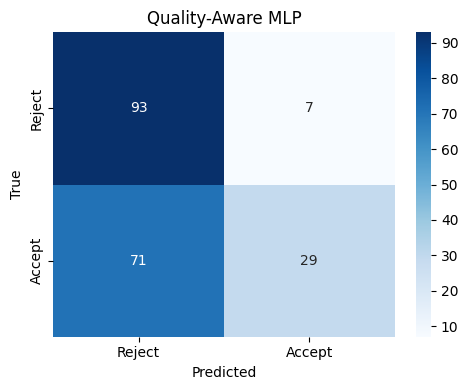

In [24]:
cm = confusion_matrix(
    y_true,
    y_pred,
)

plt.figure(figsize=(5,4))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=["Reject","Accept"],

    yticklabels=["Reject","Accept"],

)

plt.xlabel("Predicted")

plt.ylabel("True")

plt.title("Quality-Aware MLP")

plt.tight_layout()

plt.savefig(

    os.path.join(
        FIGURES_DIR,
        "mlp_african_cm.png",
    ),

    dpi=600,

    bbox_inches="tight",

)

plt.show()

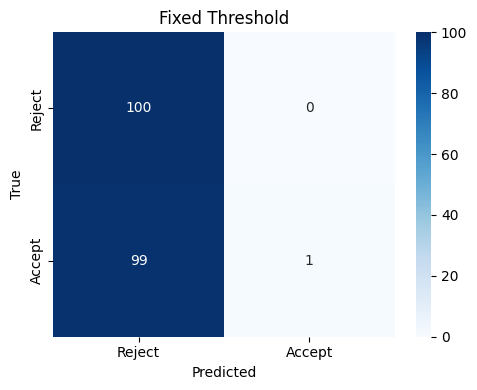

In [25]:
cm = confusion_matrix(
    y_true,
    threshold_pred,
)

plt.figure(figsize=(5,4))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=["Reject","Accept"],

    yticklabels=["Reject","Accept"],

)

plt.xlabel("Predicted")

plt.ylabel("True")

plt.title("Fixed Threshold")

plt.tight_layout()

plt.savefig(

    os.path.join(
        FIGURES_DIR,
        "threshold_african_cm.png",
    ),

    dpi=600,

    bbox_inches="tight",

)

plt.show()